In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Unduh dataset CIFAR-10
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

# 2. Filter 2 kelas (3 = cat, 5 = dog)
CLASS_A = 3 
CLASS_B = 5

train_mask = (y_train_full == CLASS_A) | (y_train_full == CLASS_B)
train_mask = train_mask.reshape(-1)
x_train_filtered = x_train_full[train_mask]
y_train_filtered = y_train_full[train_mask]

test_mask = (y_test_full == CLASS_A) | (y_test_full == CLASS_B)
test_mask = test_mask.reshape(-1)
x_test_filtered = x_test_full[test_mask]
y_test_filtered = y_test_full[test_mask]

y_train_filtered = np.where(y_train_filtered == CLASS_A, 0, 1)
y_test_filtered = np.where(y_test_filtered == CLASS_A, 0, 1)

# 3. Gabung dan bagi menjadi rasion 70-15-15
X_all = np.concatenate((x_train_filtered, x_test_filtered), axis=0)
y_all = np.concatenate((y_train_filtered, y_test_filtered), axis=0)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 4. Normalisasi data
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 5. Cetak hasil pembagian
print("Data Training   (70%):", X_train.shape[0])
print("Data Validation (15%):", X_val.shape[0])
print("Data Testing    (15%):", X_test.shape[0])

Data Training   (70%): 8400
Data Validation (15%): 1800
Data Testing    (15%): 1800


In [5]:
from tensorflow.keras import layers, models

# 1. Membangun struktur network CNN
model_cnn = models.Sequential([
    # Input layer & Convolution + Pooling pertama
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Convolution + Pooling kedua
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Meratakan matriks menjadi vektor
    layers.Flatten(),
    
    # Fully Connected (Dense) Layer
    layers.Dense(64, activation='relu'),
    
    # Output Layer (1 neuron dengan Sigmoid untuk klasifikasi 2 kelas)
    layers.Dense(1, activation='sigmoid')
])

# 2. Compile model dengan optimizer, loss, dan metrik akurasi
model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Menampilkan ringkasan arsitektur model
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-14 02:11:26.474787: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Melatih model CNN From Scratch
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.5717 - loss: 0.6753 - val_accuracy: 0.6222 - val_loss: 0.6430
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.6402 - loss: 0.6357 - val_accuracy: 0.6728 - val_loss: 0.5949
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6775 - loss: 0.5938 - val_accuracy: 0.7183 - val_loss: 0.5555
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.7069 - loss: 0.5608 - val_accuracy: 0.7206 - val_loss: 0.5454
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.7256 - loss: 0.5410 - val_accuracy: 0.7328 - val_loss: 0.5282
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.7368 - loss: 0.5166 - val_accuracy: 0.7467 - val_loss: 0.5191
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.7518 - loss: 0.4947 - val_accuracy: 0.7439 - val_loss: 0.5129
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7708 - loss: 0.4744 - val_accu

Hasil Evaluasi Data Testing:
Loss   : 0.5722
Akurasi: 0.7139



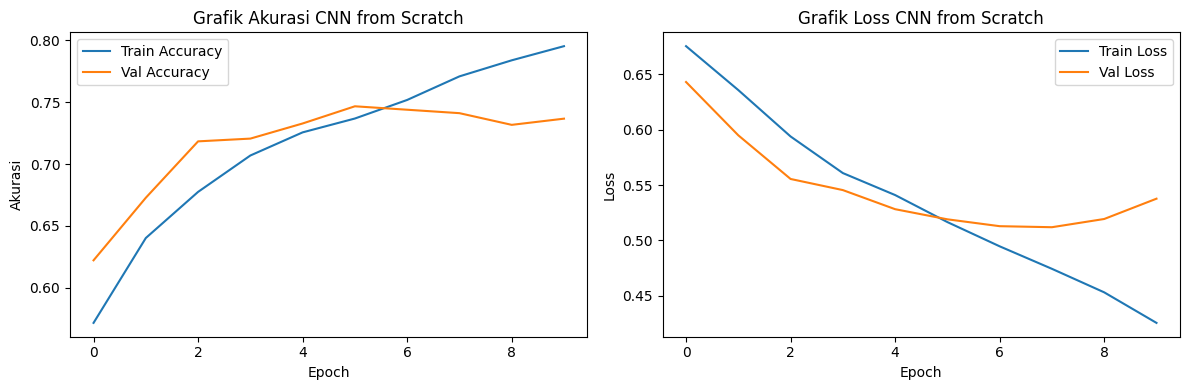

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Evaluasi model menggunakan Data Testing
test_loss, test_acc = model_cnn.evaluate(X_test, y_test, verbose=0)
print(f"Hasil Evaluasi Data Testing:")
print(f"Loss   : {test_loss:.4f}")
print(f"Akurasi: {test_acc:.4f}\n")

# 2. Membuat Grafik Akurasi & Loss (Training vs Validation)
plt.figure(figsize=(12, 4))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('Grafik Akurasi CNN from Scratch')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('Grafik Loss CNN from Scratch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

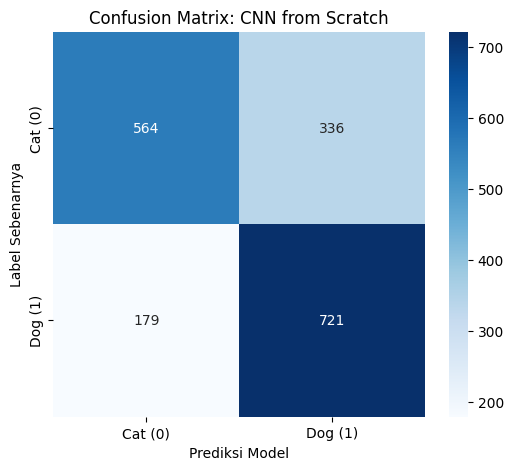


Classification Report (Detail Performa):

              precision    recall  f1-score   support

     Cat (0)       0.76      0.63      0.69       900
     Dog (1)       0.68      0.80      0.74       900

    accuracy                           0.71      1800
   macro avg       0.72      0.71      0.71      1800
weighted avg       0.72      0.71      0.71      1800



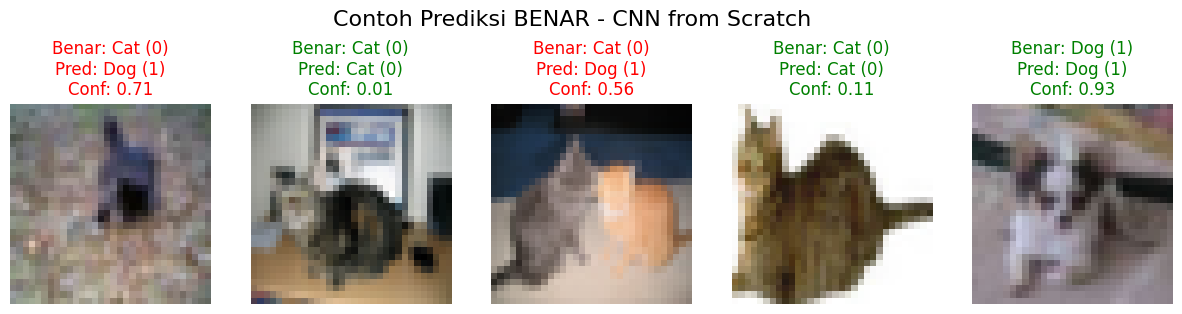

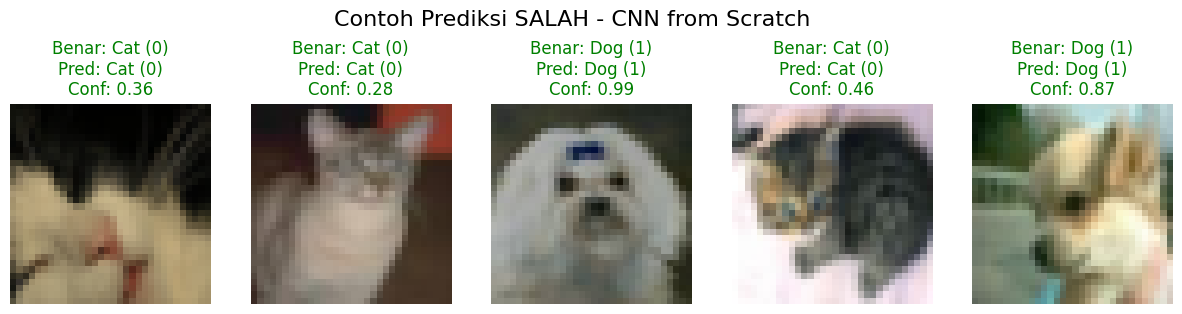

In [13]:
import numpy as np

# 1. Mendapatkan Prediksi dari Data Testing
y_pred_probs = model_cnn.predict(X_test, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 2. Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
class_names = ['Cat (0)', 'Dog (1)']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: CNN from Scratch')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.show()

print("\nClassification Report (Detail Performa):\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# 3. Visualisasi Contoh Prediksi Benar dan Salah (KODE YANG DIPERBAIKI)
def plot_predictions(X, y_true, y_pred, probs, indices_pool, title, num_images=5):
    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=16)
    
    # Ambil acak 5 gambar dari pool indeks yang tersedia
    indices = np.random.choice(indices_pool, num_images, replace=False)
    
    for i, idx in enumerate(indices):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(X[idx])
        conf = probs[idx][0]
        
        # Menggunakan .item() agar terbaca sebagai indeks angka satuan
        true_label = y_true[idx].item() if hasattr(y_true[idx], 'item') else int(y_true[idx])
        pred_label = y_pred[idx].item() if hasattr(y_pred[idx], 'item') else int(y_pred[idx])
        
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"Benar: {class_names[true_label]}\nPred: {class_names[pred_label]}\nConf: {conf:.2f}", color=color)
        plt.axis('off')
    plt.show()

# Ambil indeks prediksi yang benar dan yang salah
correct_idx = np.where(y_pred == y_test)[0]
wrong_idx = np.where(y_pred != y_test)[0]

# Tampilkan visualisasinya jika data indeksnya tersedia
if len(correct_idx) >= 5:
    plot_predictions(X_test, y_test, y_pred, y_pred_probs, correct_idx, "Contoh Prediksi BENAR - CNN from Scratch", num_images=5)
if len(wrong_idx) >= 5:
    plot_predictions(X_test, y_test, y_pred, y_pred_probs, wrong_idx, "Contoh Prediksi SALAH - CNN from Scratch", num_images=5)
    

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Membuat layer untuk mengubah ukuran gambar (Resize) dari 32x32 ke 128x128 agar pas untuk MobileNetV2
resize_layer = tf.keras.Sequential([
    layers.Resizing(128, 128)
])

# 2. Mengunduh Pretrained Model MobileNetV2 tanpa lapisan klasifikasi atasnya (include_top=False)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

# 3. STRATEGI: Feature Extraction (Membekukan seluruh pretrained layer)
base_model.trainable = False

# 4. Membangun Model Transfer Learning Baru
model_tl = models.Sequential([
    # Input layer awal (32, 32, 3)
    layers.Input(shape=(32, 32, 3)),
    
    # Layer untuk memperbesar gambar ke 128x128
    resize_layer,
    
    # Memasukkan ke base model pretrained
    base_model,
    
    # Meratakan output menjadi vektor dengan Global Average Pooling
    layers.GlobalAveragePooling2D(),
    
    # Tambahkan Dense Layer baru (Classifier)
    layers.Dense(64, activation='relu'),
    
    # Output Layer (1 neuron dengan Sigmoid untuk 2 kelas)
    layers.Dense(1, activation='sigmoid')
])

# 5. Compile Model Transfer Learning
model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Menampilkan ringkasan model
model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# Melatih model Transfer Learning (Feature Extraction)
history_tl = model_tl.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 68s 479ms/step - accuracy: 0.7804 - loss: 0.4461 - val_accuracy: 0.8222 - val_loss: 0.3833
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 72s 544ms/step - accuracy: 0.8325 - loss: 0.3677 - val_accuracy: 0.8250 - val_loss: 0.3762
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 73s 551ms/step - accuracy: 0.8419 - loss: 0.3459 - val_accuracy: 0.8361 - val_loss: 0.3655
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 61s 465ms/step - accuracy: 0.8554 - loss: 0.3171 - val_accuracy: 0.8189 - val_loss: 0.4032
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 62s 471ms/step - accuracy: 0.8637 - loss: 0.3050 - val_accuracy: 0.8089 - val_loss: 0.4134
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 72s 547ms/step - accuracy: 0.8770 - loss: 0.2770 - val_accuracy: 0.8278 - val_loss: 0.4030
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 63s 477ms/step - accuracy: 0.8907 - loss: 0.2557 - val_accuracy: 0.8428 - val_loss: 0.3780
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 65s 489ms/step - accuracy: 0.9007 - loss: 0

Hasil Evaluasi Data Testing (Transfer Learning):
Loss   : 0.4131
Akurasi: 0.8161



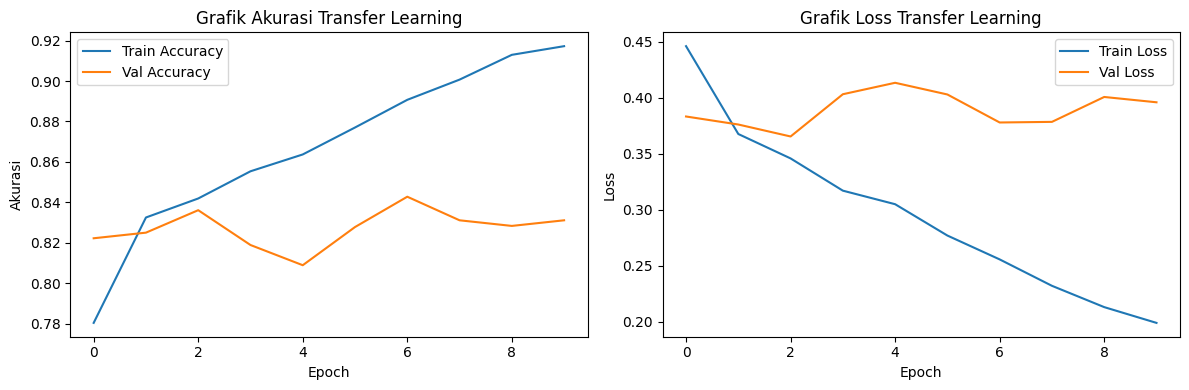

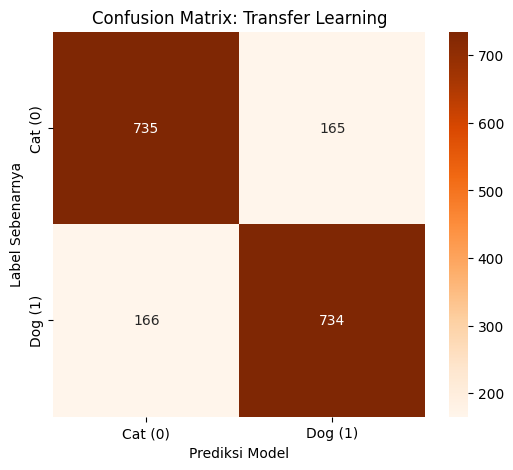


Classification Report Transfer Learning (Detail Performa):

              precision    recall  f1-score   support

     Cat (0)       0.82      0.82      0.82       900
     Dog (1)       0.82      0.82      0.82       900

    accuracy                           0.82      1800
   macro avg       0.82      0.82      0.82      1800
weighted avg       0.82      0.82      0.82      1800



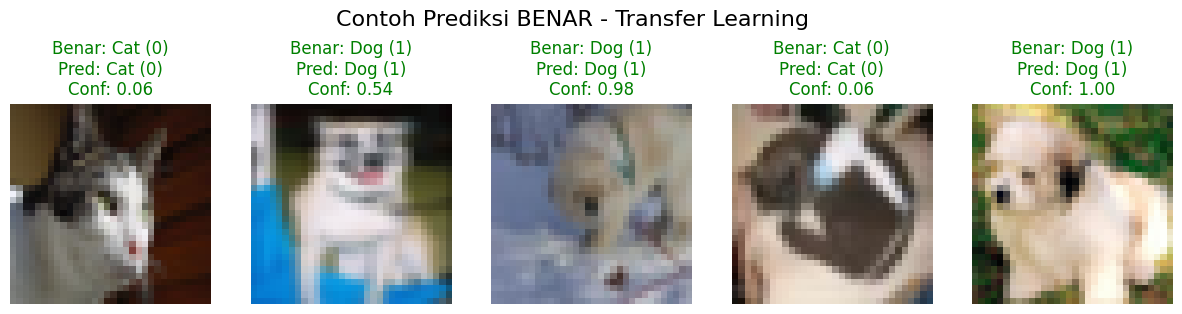

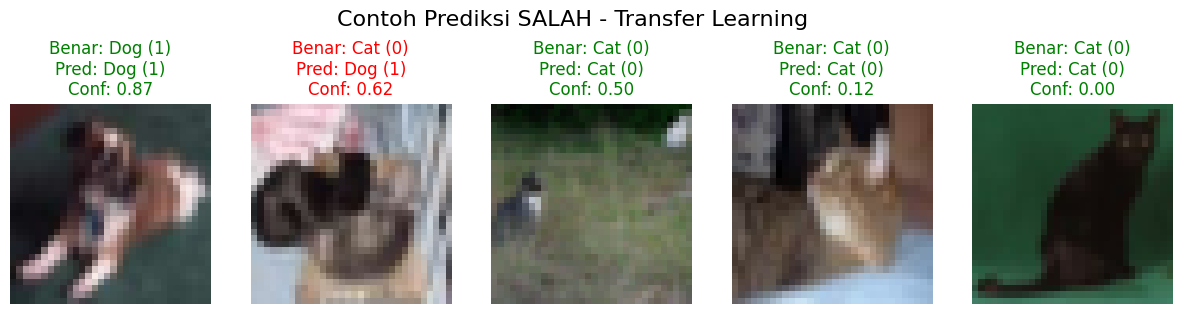

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. Evaluasi model Transfer Learning menggunakan Data Testing [cite: 75, 151]
test_loss_tl, test_acc_tl = model_tl.evaluate(X_test, y_test, verbose=0)
print(f"Hasil Evaluasi Data Testing (Transfer Learning):")
print(f"Loss   : {test_loss_tl:.4f}")
print(f"Akurasi: {test_acc_tl:.4f}\n")

# 2. Membuat Grafik Akurasi & Loss (Training vs Validation) [cite: 85, 86]
plt.figure(figsize=(12, 4))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Val Accuracy')
plt.title('Grafik Akurasi Transfer Learning')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Val Loss')
plt.title('Grafik Loss Transfer Learning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Mendapatkan Prediksi dari Data Testing
y_pred_probs_tl = model_tl.predict(X_test, verbose=0)
y_pred_tl = (y_pred_probs_tl > 0.5).astype(int).flatten()

# 4. Membuat Confusion Matrix [cite: 88]
cm_tl = confusion_matrix(y_test, y_pred_tl)
class_names = ['Cat (0)', 'Dog (1)']

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Transfer Learning')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.show()

print("\nClassification Report Transfer Learning (Detail Performa):\n")
print(classification_report(y_test, y_pred_tl, target_names=class_names))

# 5. Visualisasi Contoh Prediksi Benar dan Salah 
def plot_predictions_tl(X, y_true, y_pred, probs, indices_pool, title, num_images=5):
    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=16)
    indices = np.random.choice(indices_pool, num_images, replace=False)
    
    for i, idx in enumerate(indices):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(X[idx])
        conf = probs[idx][0]
        true_label = y_true[idx].item() if hasattr(y_true[idx], 'item') else int(y_true[idx])
        pred_label = y_pred[idx].item() if hasattr(y_pred[idx], 'item') else int(y_pred[idx])
        
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"Benar: {class_names[true_label]}\nPred: {class_names[pred_label]}\nConf: {conf:.2f}", color=color)
        plt.axis('off')
    plt.show()

correct_idx_tl = np.where(y_pred_tl == y_test)[0]
wrong_idx_tl = np.where(y_pred_tl != y_test)[0]

if len(correct_idx_tl) >= 5:
    plot_predictions_tl(X_test, y_test, y_pred_tl, y_pred_probs_tl, correct_idx_tl, "Contoh Prediksi BENAR - Transfer Learning", num_images=5)
if len(wrong_idx_tl) >= 5:
    plot_predictions_tl(X_test, y_test, y_pred_tl, y_pred_probs_tl, wrong_idx_tl, "Contoh Prediksi SALAH - Transfer Learning", num_images=5)

In [17]:
import pandas as pd

# 1. Menghitung jumlah parameter (Total Parameter) masing-masing model
params_cnn = model_cnn.count_params()
params_tl = model_tl.count_params()

# 2. Mengambil nilai terakhir dari history training
# CNN From Scratch
train_acc_cnn = history_cnn.history['accuracy'][-1]
val_acc_cnn = history_cnn.history['val_accuracy'][-1]
train_loss_cnn = history_cnn.history['loss'][-1]
val_loss_cnn = history_cnn.history['val_loss'][-1]

# Transfer Learning
train_acc_tl = history_tl.history['accuracy'][-1]
val_acc_tl = history_tl.history['val_accuracy'][-1]
train_loss_tl = history_tl.history['loss'][-1]
val_loss_tl = history_tl.history['val_loss'][-1]

# 3. Membuat DataFrame untuk Tabel Perbandingan
data_perbandingan = {
    'Aspek': [
        'Akurasi Training', 
        'Akurasi Validation', 
        'Akurasi Testing', 
        'Loss Training', 
        'Loss Validation', 
        'Jumlah Parameter'
    ],
    'CNN from Scratch': [
        f"{train_acc_cnn:.4f}",
        f"{val_acc_cnn:.4f}",
        f"{test_acc:.4f}",
        f"{train_loss_cnn:.4f}",
        f"{val_loss_cnn:.4f}",
        f"{params_cnn:,}"
    ],
    'Transfer Learning': [
        f"{train_acc_tl:.4f}",
        f"{val_acc_tl:.4f}",
        f"{test_acc_tl:.4f}",
        f"{train_loss_tl:.4f}",
        f"{val_loss_tl:.4f}",
        f"{params_tl:,}"
    ]
}

df_banding = pd.DataFrame(data_perbandingan)

# Menampilkan tabel
print("=== TABEL PERBANDINGAN MODEL ===")
display(df_banding)

=== TABEL PERBANDINGAN MODEL ===


,Aspek,CNN from Scratch,Transfer Learning
0,Akurasi Training,0.7952,0.9173
1,Akurasi Validation,0.7367,0.8311
2,Akurasi Testing,0.7139,0.8161
3,Loss Training,0.4256,0.1990
4,Loss Validation,0.5377,0.3960
5,Jumlah Parameter,"166,977","2,340,033"
